# Analysing a sinusoidal signal

### 1. In this notebook, we want to: 

2. Create functions to find and plot remarkable points
3. Analyze a known signal
4. Redo the analysis with a noisy signal

### 2. Create functions to find and plot remarkable points

##### Import libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt

##### Create the variables

In [16]:
index = [   0,     1,     2,     3,     4,     5,     6,     7,     8,     9] 
signal = [  -1,     1,     2,     1,     0,    -1,     1,     2,     1,    -2]

index = np.array(index)
signal =np.array(signal)

##### Run all the already written functions to check if they work well, add comments to understand the code, give more details about the docstring, add new tests. 

##### Find zero crossings 

In [17]:
def find_zero_crossings_no_zeros(signs: np.ndarray):#np.ndarray is a type hint indicating that the input parameter 'signs' should be a NumPy array.
    """Find zero crossings in a sign array without zeros
    
    Parameters
    ----------
    signs : np.ndarray
    One-dimensional array containing the signs of the signal,
    with -1 representing a negative value and 1 representing a positive value.
    The array must not contain zeros.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices where the sign changes from negative to positive.
    i_cross_neg : np.ndarray
        Indices where the sign changes from positive to negative.
    """ # docstring: used to describe the function's purpose 
    diff = np.diff(signs)#calculate the difference between consecutive elements in the 'signs' array. It indicates if the sign changed.
    i_cross_pos = np.where(diff > 0)[0]
    i_cross_neg = np.where(diff < 0)[0]# [0] is used to extract the indices because of the way np.where works. 
    
    return i_cross_pos, i_cross_neg


def propagate_signs_over_zeros(signs: np.ndarray):
    """Propagate non-zero signs over zero positions in the sign array:
    
    Replace zero values in a sign array with the nearest preceding non-zero sign.

    For leading zeros, the first non-zero sign is used instead.

    Parameters
    ----------
    signs : np.ndarray
        One-dimensional array containing -1, 0, and 1, representing
        negative values, zeros, and positive values.

    Returns
    -------
    signs_no_zeros : np.ndarray
        Array with zero values replaced by the corresponding non-zero sign.
        The original input array is not modified.
    """
    signs_no_zeros = signs.copy()# make a copy of the array to avoid modifying the original data.

    mask = signs_no_zeros != 0# mask creates a table where an element is True if the sign is different from zero and False if it is zero. 
    idx = np.where(mask, np.arange(len(signs_no_zeros)), 0)
    # np.where(condition, value if true, value if false), if value true : it returns the index of the element
    idx = np.maximum.accumulate(idx)# what is the maximum value of the index before the index is 0 and store it.
    # It is used because we want to give that sign to the zeros that coming after it.
    signs_no_zeros = signs_no_zeros[idx]#replace old table with the new one where the zeros are replaced by the last non-zero sign.

    if signs_no_zeros[0] == 0: #if the table starts with a zero
        i_first_nonzero = np.where(signs != 0)[0]# find the index of the first non-zero sign in the original signs array
        if len(i_first_nonzero) > 0: # if we found at least one non-zero sign
            signs_no_zeros[: i_first_nonzero[0]] = signs[i_first_nonzero[0]] # replace all leading zeros in signs_no_zeros with the first non-zero sign 

    return signs_no_zeros


def find_zero_crossings(s: np.ndarray): #the parameter here is s (signal)
    """Find zero crossings in a 1D signal array.
     The signal is first converted into its signs (-1, 0, or 1).
    If the signal contains zeros, they are replaced by the appropriate
    non-zero signs before detecting the crossings.

    Parameters
    ----------
    s : np.ndarray
        One-dimensional array containing the signal values.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices where the signal crosses zero from negative to positive.
    i_cross_neg : np.ndarray
        Indices where the signal crosses zero from positive to negative.

    Raises
    ------
    ValueError
        If the input is not a one-dimensional array."""

    s = np.asarray(s)#transform it into a numpy array if necessary
    if s.ndim != 1:#if the number of dimensions of the array is not equal to 1, it means that the input is not a 1D array.
        raise ValueError("Input must be a 1D array")

    signs = np.sign(s).astype(int) # it makes sure there is an integer number np.sign(s) returns an array of the same shape as s, 
    #where each element is -1 if the corresponding element in s is negative, 0 if it is zero, and 1 if it is positive.
    i_zeros = np.where(signs == 0)[0]
    if i_zeros.size > 0: #if there are zeros
        signs_no_zeros = propagate_signs_over_zeros(signs)#use the propagate_signs_over_zeros function to replace zeros with the last non-zero sign.
    else:
        signs_no_zeros = signs

    return find_zero_crossings_no_zeros(signs_no_zeros)

##### Test the previous function

In [18]:
# this function is used to test the find_zero_crossings function with various test cases to ensure it behaves as expected.

def test_find_zero_crossings():
    """Test the find_zero_crossings function with several signal configurations.

    The tests check positive and negative zero crossings for signals with
    alternating signs, zeros between non-zero values, leading zeros,
    and signals with no zero crossings.

    Returns
    -------
    None
        This function raises an AssertionError if one of the tests fails.
    """
    # Test with an array of alternating signs
    s = np.array([-1, 1, -1, 1, -1]) #example of an array with alternating signs
    # expected     +  -   +  -   +
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([0, 2])) #we expect positive crossings at index 0 and 2
    # we use index but the change of sign is between the two values(so the two indices), we use the first index to represent the change of sign.
    assert np.array_equal(i_neg, np.array([1, 3]))
    
    #same logic for the following tests

    # Test with zeros between non-zero values
    s = np.array([-1, 0, 0, 1, 0, -1])
    # expected     -     +     -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([2]))
    assert np.array_equal(i_neg, np.array([4]))

    # Test with leading zeros and only positive values
    s = np.array([0, 0, 0, 1, 0, 0])
    # expected    no crossings
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))

    # Test with leading zeros and detect negative crossings with a zero in between
    s = np.array([0, 0, 1, 0, -1, 0])
    # expected             -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))

    # Test with leading zeros and detect negative crossings with zeros in between
    s = np.array([0, 1, 0, 0, -1, 0])
    # expected             -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))

    # Test if it detects negative crossings with zeros before and after the negative value
    s = np.array([1, 0, 0, -1, 0, 0])
    # expected          -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([2]))
    
    # Add new tests 
    
    # Test a signal containing only positive values
    s = np.array([1, 1, 1, 1])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))
    
    # Test a signal containing only negative values
    s = np.array([-1, -1, -1, -1])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))
   
    # Test a signal containing only zeros
    s = np.array([0, 0, 0, 0])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))
    
    # Test a signal containing only one element
    s = np.array([1])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))
    
    # Test a single negative-to-positive zero crossing
    s = np.array([-1, 1])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([0]))
    assert np.array_equal(i_neg, np.array([]))
    
    # Test a single positive-to-negative zero crossing
    s = np.array([1, -1])
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([0]))
    
    


# Testing the function
try:# why not if? because here we try a code we do not test a condition
    test_find_zero_crossings()
    print("All tests passed.")
except AssertionError:
    raise  # propagate the error, if it fails I want python to tell me which test failed and why.

All tests passed.


##### Plot the signal and the zero crossings

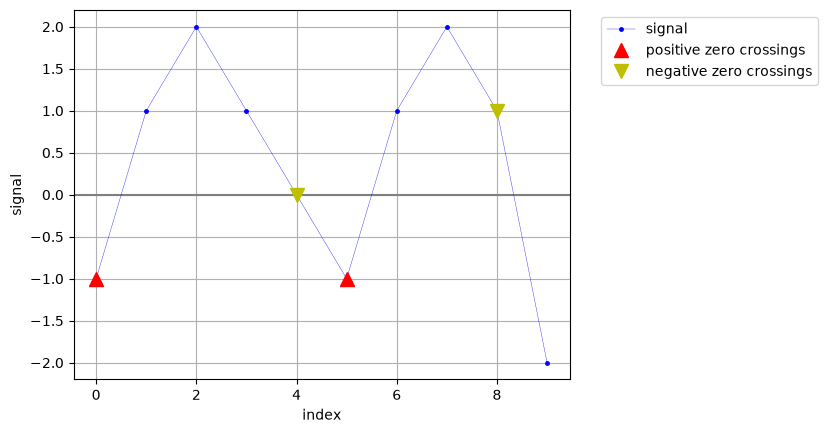

In [19]:
def plot_signal(i: np.ndarray, s: np.ndarray, color: str = "blue"):#(x,y)
    """Plot the signal as function of time/index with grid and zero line"""
    plt.axhline(y=0, color="gray", linestyle="-")  # before to be under the signal
    plt.plot(i, s, ".-", markersize=5, linewidth=0.25, color=color, label="signal")# ".-" : connect the points with a line
    plt.ylabel("signal")
    plt.xlabel("index")


def plot_remarkable_points(t: np.ndarray, s: np.ndarray, format: str, label: str): #str : in text format
    """Plot remarkable points on a signal with format and label"""
    plt.plot(t, s, format, markersize=10, label=label)


def plot_positive_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot positive zero crossings on a signal"""
    i_pos, _ = find_zero_crossings(s) # '_' is used to ignore the second return value (negative zero crossings)
    plot_remarkable_points(i[i_pos], s[i_pos], "^r", "positive zero crossings")#"^r": upward-pointing triangle in red color


def plot_negative_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot negative zero crossings on a signal"""
    _, i_neg = find_zero_crossings(s)
    plot_remarkable_points(i[i_neg], s[i_neg], "vy", "negative zero crossings")#"vy": downward-pointing triangle in yellow color


def plot_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot all zero crossings on a signal"""
    plot_positive_zero_crossings(i, s)
    plot_negative_zero_crossings(i, s)


def display_signal_and_crossings(i: np.ndarray, s: np.ndarray):
    """Plot signal and zero crossings with legend outside the plot and grid"""
    plt.figure()
    plot_signal(i, s)
    plot_positive_zero_crossings(i, s)# why using this funcion instead the one we just created ? 
    plot_negative_zero_crossings(i, s)
    # NOTE: legend outside does not work well with %matplotlib widget
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()


# Example usage
display_signal_and_crossings(index, signal)

##### Create new functions to find the local maxima and minima

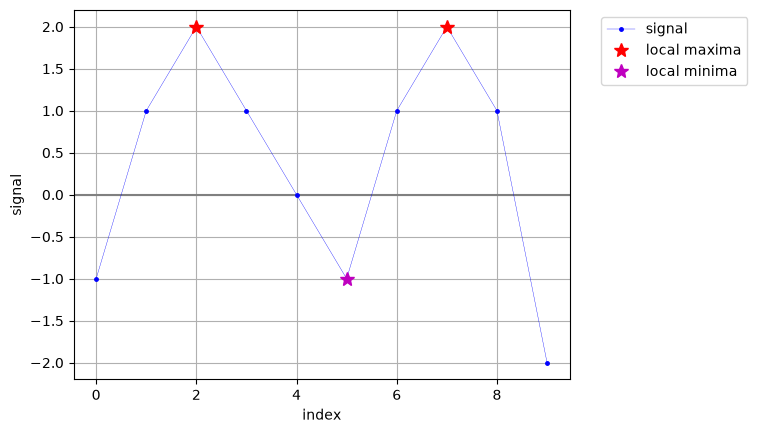

In [29]:
def find_local_extrema(signal: np.ndarray):
    """
    Find local maxima and minima in a 1D signal array.

    Parameters
    ----------
    signal : np.ndarray
        One-dimensional array containing the signal values.

    Returns
    -------
    i_max : np.ndarray
        Indices of the local maxima.
    i_min : np.ndarray
        Indices of the local minima.
    """
    # Find the differences between consecutive elements
    diff = np.diff(signal)

    # Find where the difference changes from positive to negative (local max)
    i_max = np.where((diff[:-1] > 0) & (diff[1:] < 0))[0] + 1 #+1 is used to adjust the indices because np.diff reduces the length of the array by 1.
    # [:-1] is used to exclude the last element of the diff array, and [1:] is used to exclude the first element of the diff array to compare each difference with the following one
    # Find where the difference changes from negative to positive (local min)
    i_min = np.where((diff[:-1] < 0) & (diff[1:] > 0))[0] + 1

    return i_max, i_min


def plot_local_extrema(i: np.ndarray, s: np.ndarray):
    """Plot local maxima and minima on a signal"""
    i_max, i_min = find_local_extrema(s)
    plot_remarkable_points(i[i_max], s[i_max], "*r", "local maxima")  # "*g": green stars for local maxima
    plot_remarkable_points(i[i_min], s[i_min], "*m", "local minima")  # "*m": magenta stars for local minima

def display_signal_and_extrema(i: np.ndarray, s: np.ndarray):
    """Plot signal and local extrema."""

    plt.figure()

    plot_signal(i, s)
    plot_local_extrema(i, s)

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()
    
display_signal_and_extrema(index, signal)


### 3. Create the signal and plot it

##### Plot new signals

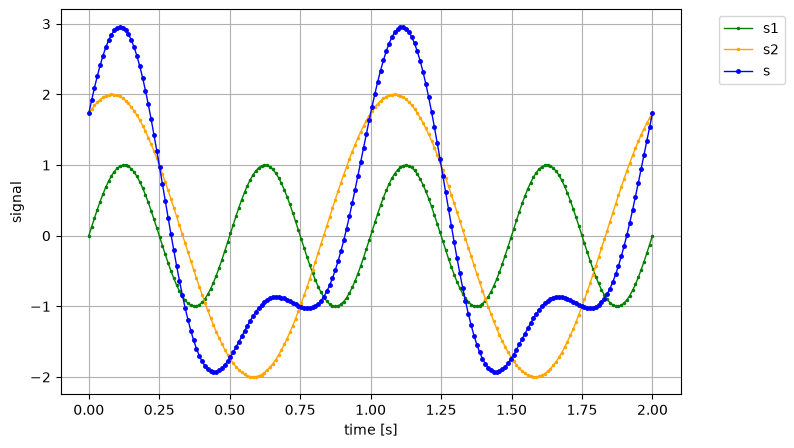

In [54]:
def create_sine_wave(t, amplitude, frequency, phase=0):
    
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)

# Create time array
t = np.linspace(0, 2, 200)


# Create the two sine waves
s1 = create_sine_wave(t, amplitude=1, frequency=2.0)
s2 = create_sine_wave(t, amplitude=2, frequency=1, phase=np.pi/3)


# Combine the two signals
s = s1 + s2

# Plot the signals
plt.figure(figsize=(8, 5))

plt.plot(t, s1, ".-",color="green", markersize=3,linewidth=1, label="s1")
plt.plot(t, s2, ".-",color="orange", markersize=3,linewidth=1, label="s2")
plt.plot(t, s, ".-",color="blue", markersize=5,linewidth=1, label="s")

plt.xlabel("time [s]")
plt.ylabel("signal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

